# Analysis of Solar Power Generation Dataset
### Prof: José Ramón Iglesias Gamarra - especialización Energías Renovables - Universidad Popular del Cesar


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read the .CSV files into Pandas dataframe
df_p1_gen = pd.read_csv('Plant_1_Generation_Data.csv')
df_p1_sens = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
df_p2_gen = pd.read_csv('Plant_2_Generation_Data.csv')
df_p2_sens = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

df_list = [df_p1_gen, df_p1_sens, df_p2_gen, df_p2_sens]
name_list = ['Plant_1_Generation_Data', 'Plant_1_Weather_Sensor_Data', 'Plant_2_Generation_Data', 'Plant_2_Weather_Sensor_Data']

## Data Transformation and Cleaning

#### Datasets contain no null values:

In [3]:
for df in df_list:
    print('*********************************************************************************')
    print(f"This dataset has \033[1m{df.shape[0]}\033[0m rows and \033[1m{df.shape[1]}\033[0m columns.")
    print('-------------------------------------------')
    print(df.head(2))
    print('-------------------------------------------')
    print(df.info())
    print("\033[1mNo column contains Null values.\033[0m")
    print('-------------------------------------------')
    print(df.describe())
    print("PLANT_ID has no duplicated and is the primary key.\n\n\n")

*********************************************************************************
This dataset has 68778 rows and 7 columns.
-------------------------------------------
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
-------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64


#### Columns for the two "generation" datasets and the two "weather sensor" datasets are identical

In [4]:
print('\033[1mThe two "Generation" datasets contain identical columns:\033[0m\n')
print(df_p1_gen.columns == df_p2_gen.columns,'\n')
print(df_p1_gen.columns)
print('')
print('\033[1mThe two "Weather Sensor" datasets contain identical columns:\033[0m\n')
print(df_p1_sens.columns == df_p2_sens.columns,'\n')
print(df_p1_sens.columns)

The two "Generation" datasets contain identical columns:

[ True  True  True  True  True  True  True] 

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

The two "Weather Sensor" datasets contain identical columns:

[ True  True  True  True  True  True] 

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


#### "Date-Time" columns for the datasets need to be converted to "datetime64" format:

In [5]:
print(f"for all datasets, the 'Date_Time' column has \033[1m{df_p1_gen.dtypes['DATE_TIME']}\033[0m type.")
#To convert them to "date and time" format:
df_list[0]['DATE_TIME'] = pd.to_datetime(df_list[0]['DATE_TIME'], dayfirst=True).dt.strftime('%Y-%m-%d %H:%M:%S')
for df in df_list:
    print(df.iloc[0,0])
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
print(f"\nNow the 'Date_Time' columns in all data sets have \033[1m{df_p1_gen.dtypes['DATE_TIME']}\033[0m format")
for df in df_list:
    print(df.iloc[0,0])

for all datasets, the 'Date_Time' column has object type.
2020-05-15 00:00:00
2020-05-15 00:00:00
2020-05-15 00:00:00
2020-05-15 00:00:00

Now the 'Date_Time' columns in all data sets have datetime64[ns] format
2020-05-15 00:00:00
2020-05-15 00:00:00
2020-05-15 00:00:00
2020-05-15 00:00:00


#### The date range for all 4 datasets are identical. 
#### The 4 datasets start on 2020-05-15 midnight and end on 2020-06-17 23:45:00.

In [6]:
for i in range(len(name_list)):
    print(f"{name_list[i]}'s start date is \033[1m{df_list[i].iloc[0].loc['DATE_TIME']}\033[0m and final date is \033[1m{df_list[i].iloc[-1].loc['DATE_TIME']}\033[0m.\n")


Plant_1_Generation_Data's start date is 2020-05-15 00:00:00 and final date is 2020-06-17 23:45:00.

Plant_1_Weather_Sensor_Data's start date is 2020-05-15 00:00:00 and final date is 2020-06-17 23:45:00.

Plant_2_Generation_Data's start date is 2020-05-15 00:00:00 and final date is 2020-06-17 23:45:00.

Plant_2_Weather_Sensor_Data's start date is 2020-05-15 00:00:00 and final date is 2020-06-17 23:45:00.



#### The two "generation" datasets contain different number of rows (mainly 22 rows) for every 15 minutes time stamp.
#### For "weather sensor" datasets, there is only 1 row per each 15 minutes time stamp.

In [7]:
for i in range(len(df_list)):
    print(f"{name_list[i]}: \n-----\n{df_list[i].groupby('DATE_TIME').count()['PLANT_ID'].value_counts()}\n")

Plant_1_Generation_Data: 
-----
PLANT_ID
22    3057
10      32
21      27
14      23
18      14
4        2
20       1
16       1
19       1
Name: count, dtype: int64

Plant_1_Weather_Sensor_Data: 
-----
PLANT_ID
1    3182
Name: count, dtype: int64

Plant_2_Generation_Data: 
-----
PLANT_ID
22    2355
18     840
12      64
Name: count, dtype: int64

Plant_2_Weather_Sensor_Data: 
-----
PLANT_ID
1    3259
Name: count, dtype: int64



#### Extract "date" and "time" from "date_time" column and store them in separate columns:

In [8]:
for df in df_list:
    df['DATE'] = df['DATE_TIME'].dt.strftime('%Y-%m-%d')
    df['DATE'] = df['DATE_TIME'].dt.normalize()
    df['TIME'] = df['DATE_TIME'].dt.strftime("%H:%M:%S")

#### For some of the future analysis, we group the "generation" datasets based on the average of every 15 min data.
#### The granularity for "weather sensor" datasets already limited to 15 min time stamps.

In [9]:
df_group = []
df_group.append(df_list[0].groupby('DATE_TIME').mean('numeric_only').reset_index())
df_group.append(df_list[1])
df_group.append(df_list[2].groupby('DATE_TIME').mean('numeric_only').reset_index())
df_group.append(df_list[3])

In [10]:
for i in range(len(df_list)):
    print(f"{name_list[i]}: \n-----\n{df_group[i].groupby('DATE_TIME').count()['PLANT_ID'].value_counts()}\n")

Plant_1_Generation_Data: 
-----
PLANT_ID
1    3158
Name: count, dtype: int64

Plant_1_Weather_Sensor_Data: 
-----
PLANT_ID
1    3182
Name: count, dtype: int64

Plant_2_Generation_Data: 
-----
PLANT_ID
1    3259
Name: count, dtype: int64

Plant_2_Weather_Sensor_Data: 
-----
PLANT_ID
1    3259
Name: count, dtype: int64



#### Now, all datasets contain 1 row per 15 minutes timestamp
#### Extracting "date" from "date_time" columns in df_group data.

In [11]:
for df in df_group:
    df['DATE'] = df['DATE_TIME'].dt.strftime('%Y-%m-%d')
    df['DATE'] = df['DATE_TIME'].dt.normalize()

In [12]:
df_group[0].head(2)

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,DATE
0,2020-05-15 00:00:00,4135001.0,0.0,0.0,0.0,6.837223e+06,2020-05-15
1,2020-05-15 00:15:00,4135001.0,0.0,0.0,0.0,6.837223e+06,2020-05-15


## Data Exploration and Visualization

### Comparing Ambient and Module Temperature distribution for the two Solar Plants:
#### First, concatenate the two "weather sensor" datasets in one dataset:

In [13]:
concat_weather = pd.concat([df_group[1], df_group[3]], ignore_index=True)

In [14]:
concat_weather.head(3)

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,TIME
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,2020-05-15,00:00:00
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,2020-05-15,00:15:00
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,2020-05-15,00:30:00


#### Second, plot the ambient and module temperature for the two datasets using seaborn displot:
#### Plant-2 in average experienced 2.6 $^\circ$C higher ambient temperature than Plant-1. 
#### Plant-2 in average experienced 1.7 $^\circ$C higher module temperature than Plant-1. 

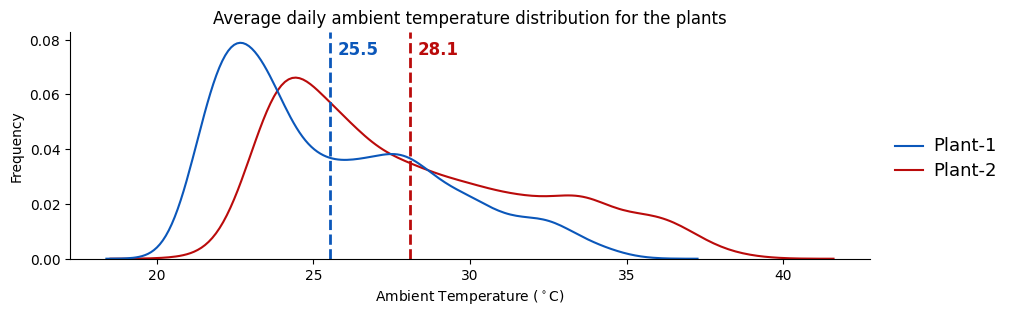

In [15]:
g = sns.displot(data=concat_weather,x='AMBIENT_TEMPERATURE',kind='kde',hue='PLANT_ID',height=3, aspect=3, palette=['#0b57ba','#ba0b0b'])
new_labels = ['Plant-1', 'Plant-2']
g._legend.set_title(None)
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
for text in g._legend.texts:
    text.set_fontsize(13)
plt.axvline(df_group[1]['AMBIENT_TEMPERATURE'].mean(), color='#0b57ba', lw=2, ls='--')
plt.axvline(df_group[3]['AMBIENT_TEMPERATURE'].mean(), color='#ba0b0b', lw=2, ls='--')
plt.text(
    df_group[1]['AMBIENT_TEMPERATURE'].mean() + 0.25,  # Adjust horizontal position slightly
    plt.ylim()[1] * 0.9,  # Position text near the top
    f'{df_group[1]["AMBIENT_TEMPERATURE"].mean():.1f}',  # Format to 2 decimal places
    color='#0b57ba',
    fontsize=12,
    fontweight='bold'
)
plt.text(
    df_group[3]['AMBIENT_TEMPERATURE'].mean() + 0.25,  # Adjust horizontal position slightly
    plt.ylim()[1] * 0.9,  # Position text near the top
    f'{df_group[3]["AMBIENT_TEMPERATURE"].mean():.1f}',  # Format to 2 decimal places
    color='#ba0b0b',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Ambient Temperature ($^\circ$C)')
plt.ylabel('Frequency')
plt.title('Average daily ambient temperature distribution for the plants')
plt.show()

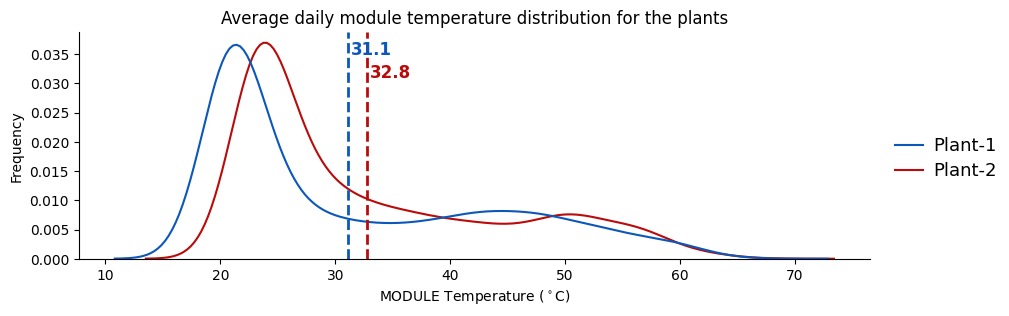

In [16]:
g = sns.displot(data=concat_weather,x='MODULE_TEMPERATURE',kind='kde',hue='PLANT_ID',height=3, aspect=3, palette=['#0b57ba','#ba0b0b'])
new_labels = ['Plant-1', 'Plant-2']
g._legend.set_title(None)
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
for text in g._legend.texts:
    text.set_fontsize(13)
plt.axvline(df_group[1]['MODULE_TEMPERATURE'].mean(), color='#0b57ba', lw=2, ls='--')
plt.axvline(df_group[3]['MODULE_TEMPERATURE'].mean(), color='#ba0b0b', lw=2, ls='--')
plt.text(
    df_group[1]['MODULE_TEMPERATURE'].mean() + 0.25,  # Adjust horizontal position slightly
    plt.ylim()[1] * 0.9,  # Position text near the top
    f'{df_group[1]["MODULE_TEMPERATURE"].mean():.1f}',  # Format to 2 decimal places
    color='#0b57ba',
    fontsize=12,
    fontweight='bold'
)
plt.text(
    df_group[3]['MODULE_TEMPERATURE'].mean() + 0.25,  # Adjust horizontal position slightly
    plt.ylim()[1] * 0.8,  # Position text near the top
    f'{df_group[3]["MODULE_TEMPERATURE"].mean():.1f}',  # Format to 2 decimal places
    color='#ba0b0b',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('MODULE Temperature ($^\circ$C)')
plt.ylabel('Frequency')
plt.title('Average daily module temperature distribution for the plants')
plt.show()

### Comparing ambient and module temperature for each plant.
#### First, averaging datasets by "date" column to obtain average daily temperatures.

In [17]:
df_daily_temp_plant_1 = df_group[1].groupby('DATE').mean('numeric_only').reset_index()
df_daily_temp_plant_2 = df_group[3].groupby('DATE').mean('numeric_only').reset_index()

In [18]:
df_daily_temp_plant_1.head(2)

,DATE,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001.0,27.430823,32.582964,0.204699
1,2020-05-16,4135001.0,26.780538,31.858851,0.211951


##### Plant-1
#### Average module temperature is 5.6 $^\circ$C higher than average ambient temperature.
#### The ambient and module daily temperature somehow correlated, which means changes in the module temperature are likely due to changes in the ambient temperature.

In [19]:
print(f"Correlation factor for ambient and module temperature for Plant-1 are: {round(df_daily_temp_plant_1['AMBIENT_TEMPERATURE'].corr(df_daily_temp_plant_1['MODULE_TEMPERATURE']),3)}")

Correlation factor for ambient and module temperature for Plant-1 are: 0.891


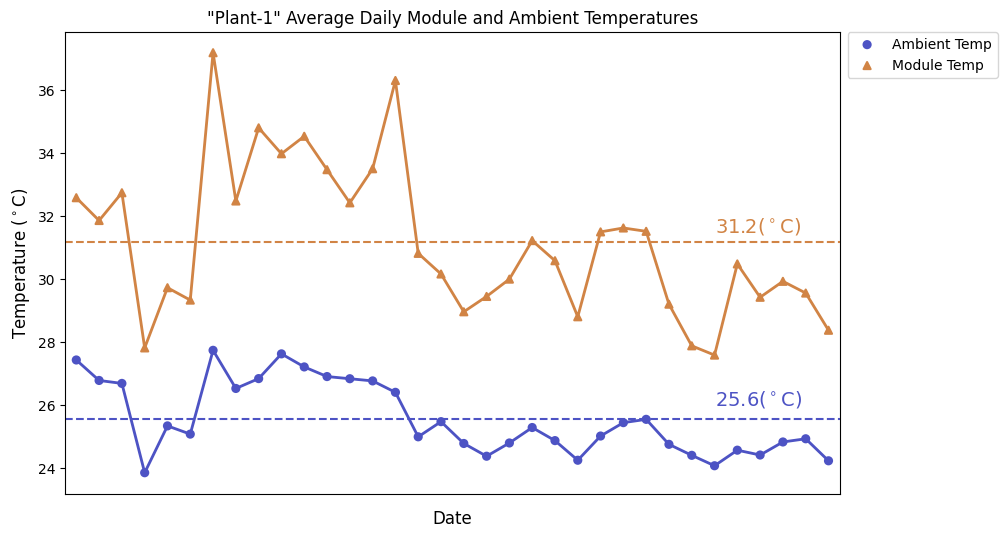

In [20]:
plt.figure(figsize=(10, 6))
fig = sns.pointplot(data=df_daily_temp_plant_1,x='DATE',y='AMBIENT_TEMPERATURE',color='#4d53c4',label='Ambient Temp',scale=0.75)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
fig.set(xticklabels=[]) 

fig.tick_params(bottom=False)

fig = sns.pointplot(data=df_daily_temp_plant_1,x='DATE',y='MODULE_TEMPERATURE',color='#d18445',label='Module Temp',markers='^',scale=0.75)
fig.set(xticklabels=[]) 
fig.tick_params(bottom=False)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.ylabel('Temperature ($^\circ$C)', fontsize=12)

plt.xlabel('Date', fontsize=12)
plt.title('"Plant-1" Average Daily Module and Ambient Temperatures')
plt.axhline(y = round(np.average(df_daily_temp_plant_1['AMBIENT_TEMPERATURE']),2), color = '#4d53c4', linestyle = 'dashed') 
plt.axhline(y = round(np.average(df_daily_temp_plant_1['MODULE_TEMPERATURE']),2), color = '#d18445', linestyle = 'dashed')

plt.text(28, 26, f"{round(np.average(df_daily_temp_plant_1['AMBIENT_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#4d53c4')
plt.text(28, 31.5, f"{round(np.average(df_daily_temp_plant_1['MODULE_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#d18445')
plt.show()

##### Plant-2
#### Average module temperature is 4.7 $^\circ$C higher than average ambient temperature.
#### The ambient and module daily temperature are correlated, which means changes in the module temperature are primarily due to changes in the ambient temperature.

In [21]:
print(f"Correlation factor for ambient and module temperatures for Plant-2 are: {round(df_daily_temp_plant_2['AMBIENT_TEMPERATURE'].corr(df_daily_temp_plant_2['MODULE_TEMPERATURE']),3)}")

Correlation factor for ambient and module temperatures for Plant-2 are: 0.965


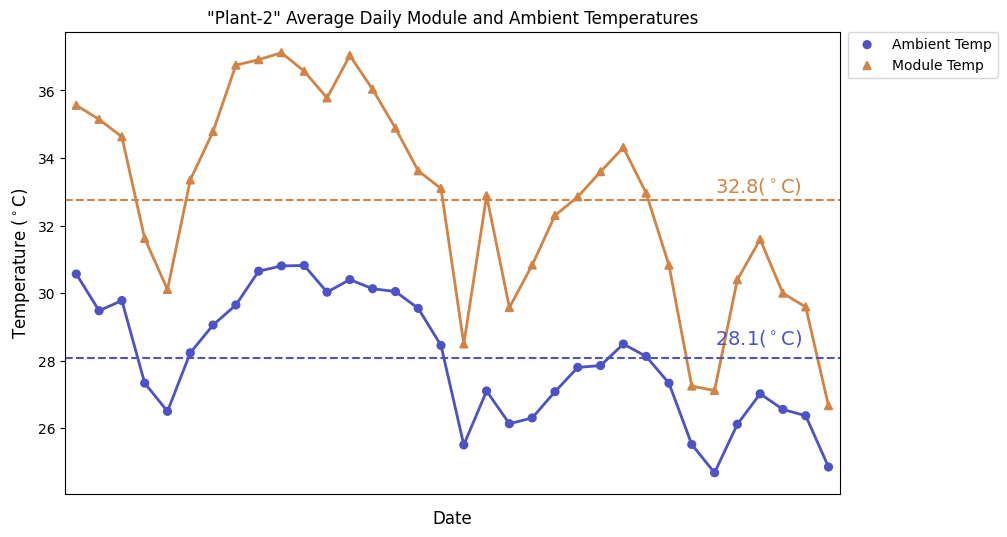

In [22]:
plt.figure(figsize=(10, 6))
fig = sns.pointplot(data=df_daily_temp_plant_2,x='DATE',y='AMBIENT_TEMPERATURE',color='#4d53c4',label='Ambient Temp',scale=0.75)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
fig.set(xticklabels=[]) 

fig.tick_params(bottom=False)

fig = sns.pointplot(data=df_daily_temp_plant_2,x='DATE',y='MODULE_TEMPERATURE',color='#d18445',label='Module Temp',markers='^',scale=0.75)
fig.set(xticklabels=[]) 
fig.tick_params(bottom=False)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.ylabel('Temperature ($^\circ$C)', fontsize=12)

plt.xlabel('Date', fontsize=12)
plt.title('"Plant-2" Average Daily Module and Ambient Temperatures')
plt.axhline(y = round(np.average(df_daily_temp_plant_2['AMBIENT_TEMPERATURE']),2), color = '#4d53c4', linestyle = 'dashed') 
plt.axhline(y = round(np.average(df_daily_temp_plant_2['MODULE_TEMPERATURE']),2), color = '#d18445', linestyle = 'dashed')

plt.text(28, 28.5, f"{round(np.average(df_daily_temp_plant_2['AMBIENT_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#4d53c4')
plt.text(28, 33, f"{round(np.average(df_daily_temp_plant_2['MODULE_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#d18445')
plt.show()

### Evaluating Output Power (AC & DC) 

#### Plots below shows the average daily AC and DC Power output for Plant-1 and Plant-2, respectively.

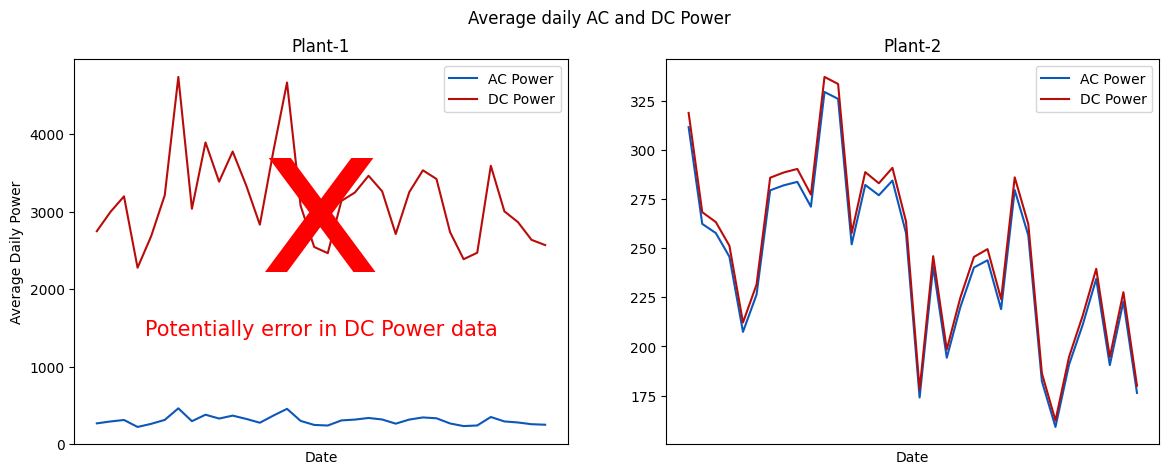

In [23]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5))
fig.suptitle('Average daily AC and DC Power')

sns.lineplot(ax=axes[0],data = df_group[0].groupby('DATE').mean().reset_index(),x='DATE',y='AC_POWER',errorbar=None,color = '#0b57ba',label='AC Power')
sns.lineplot(ax=axes[0],data = df_group[0].groupby('DATE').mean().reset_index(),x='DATE',y='DC_POWER',errorbar=None,color = '#ba0b0b',label='DC Power')
# sns.scatterplot(ax=axes[0],x=['2020-06-25'],y=[2500],s=100)
axes[0].text(x=0.5,y=0.6,s='x',horizontalalignment='center', verticalalignment='center',transform=axes[0].transAxes,color='r',fontsize=150)
axes[0].text(x=0.5,y=0.3,s='Potentially error in DC Power data',horizontalalignment='center', verticalalignment='center',transform=axes[0].transAxes,color='r',fontsize=15)
axes[0].set_title("Plant-1")
axes[0].set_xticklabels([])
axes[0].set_xticks([])
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Daily Power')
plt.title('Plant-1')
sns.lineplot(ax=axes[1],data = df_group[2].groupby('DATE').mean().reset_index(),x='DATE',y='AC_POWER',errorbar=None,color = '#0b57ba',label='AC Power')
sns.lineplot(ax=axes[1],data = df_group[2].groupby('DATE').mean().reset_index(),x='DATE',y='DC_POWER',errorbar=None,color = '#ba0b0b',label='DC Power')
plt.xticks(rotation=30)
axes[1].set_xlabel('Date')
axes[1].set_ylabel(None)
axes[1].set_title("Plant-2")
axes[1].set_xticklabels([])
axes[1].set_xticks([])
plt.title('Plant-2')
plt.show()

#### Generally, DC and AC power outputs for Solar panels are expected to be in the same range where AC power is slightly less than DC power caused by the efficiency of inverter. Therefore, DC power data and its range for plant-1 seem unreasonable.

### Evaluating Daily Yield of each plant

#### First, grouping data by date to obtain maximum daily yield for each day.

In [24]:
df_daily_yield = [df_group[0].groupby('DATE').max('DAILY_YIELD').reset_index(),df_group[2].groupby('DATE').max('DAILY_YIELD').reset_index()]

In [25]:
df_daily_yield[1].head(2)

,DATE,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4136001.0,917.966082,897.937359,7403.454545,6.449890e+08
1,2020-05-16,4136001.0,963.401212,942.151883,6305.272727,6.449953e+08


#### Average daily yield for plant-1 is 21.0% higher than plant-2 

In [26]:
print(f"Average daily yield for plant-1 is: {round(np.average(df_daily_yield[0]['DAILY_YIELD']),2)}")
print(f"Average daily yield for plant-2 is: {round(np.average(df_daily_yield[1]['DAILY_YIELD']),2)}")

print(f"The average daily yield for plant-1 is {round((np.average(df_daily_yield[0]['DAILY_YIELD'])-np.average(df_daily_yield[1]['DAILY_YIELD']))/(np.average(df_daily_yield[1]['DAILY_YIELD'])),2)*100}% higher than plant-2")

Average daily yield for plant-1 is: 7196.59
Average daily yield for plant-2 is: 5949.21
The average daily yield for plant-1 is 21.0% higher than plant-2


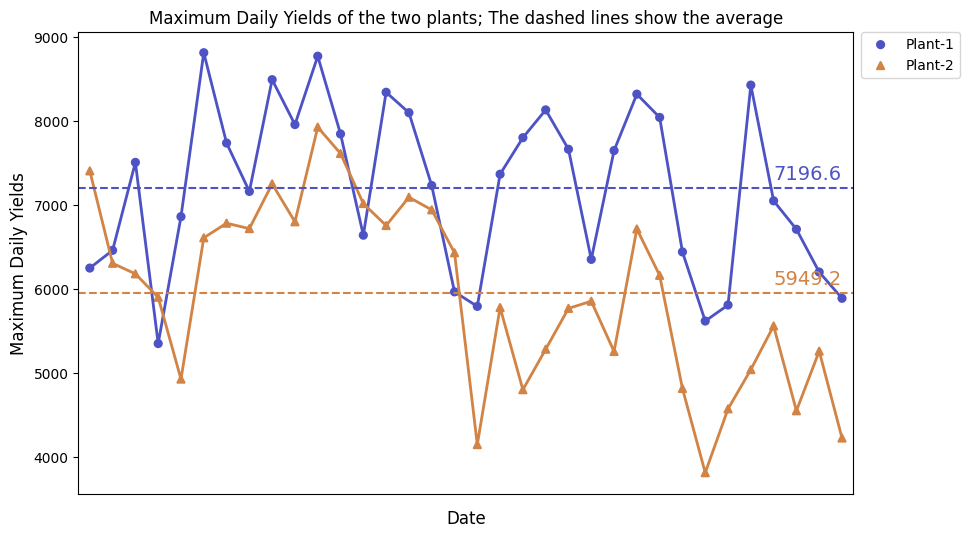

In [27]:
plt.figure(figsize=(10, 6))
fig = sns.pointplot(data=df_daily_yield[0],x='DATE',y='DAILY_YIELD',color='#4d53c4',label='Plant-1',scale=0.75)
fig = sns.pointplot(data=df_daily_yield[1],x='DATE',y='DAILY_YIELD',color='#d18445',label='Plant-2',markers='^',scale=0.75)
fig.set(xticklabels=[]) 
plt.axhline(y = round(np.average(df_daily_yield[0]['DAILY_YIELD']),2), color = '#4d53c4', linestyle = 'dashed') 
plt.axhline(y = round(np.average(df_daily_yield[1]['DAILY_YIELD']),2), color = '#d18445', linestyle = 'dashed')

plt.text(30, 7300, f"{round(np.average(df_daily_yield[0]['DAILY_YIELD']),1)}", fontsize = 14,color='#4d53c4')
plt.text(30, 6050, f"{round(np.average(df_daily_yield[1]['DAILY_YIELD']),1)}", fontsize = 14,color='#d18445')

fig.tick_params(bottom=False)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.ylabel('Maximum Daily Yields', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Maximum Daily Yields of the two plants; The dashed lines show the average')

plt.show()

### Effect of temperature on yield

In [28]:
df_daily_yield[0].head(2)

,DATE,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001.0,11809.694805,1152.388474,6248.772727,6.918639e+06
1,2020-05-16,4135001.0,11154.736201,1088.891558,6459.727273,6.921569e+06


In [29]:
df_daily_temp_plant_1.head(2)

,DATE,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001.0,27.430823,32.582964,0.204699
1,2020-05-16,4135001.0,26.780538,31.858851,0.211951


#### There is no remarkable correlation between the module temperature and the daily yield in plant-1. 
#### There is a strong correlation between the module temperature and the daily yield in plant-2.

#### Similar correlations could be identified between the daily yeild and the ambient temperature.

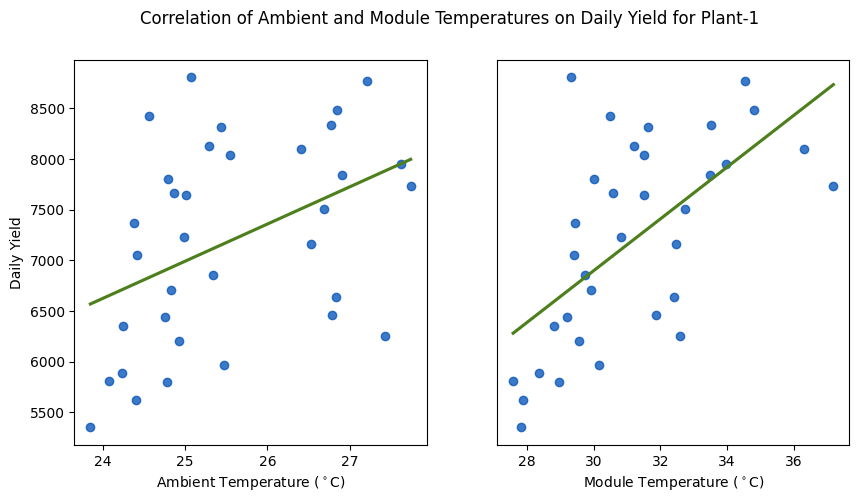

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Correlation of Ambient and Module Temperatures on Daily Yield for Plant-1')
sns.regplot(ax=axes[0],x=df_daily_temp_plant_1['AMBIENT_TEMPERATURE'],y=df_daily_yield[0]['DAILY_YIELD'],line_kws=dict(color="#4d801d"),color="#0b57ba",ci = None)
axes[0].set_xlabel('Ambient Temperature ($^\circ$C)')
axes[0].set_ylabel('Daily Yield')
sns.regplot(ax=axes[1],x=df_daily_temp_plant_1['MODULE_TEMPERATURE'],y=df_daily_yield[0]['DAILY_YIELD'],line_kws=dict(color="#4d801d"),color="#0b57ba",ci = None)
axes[1].set_xlabel('Module Temperature ($^\circ$C)')
axes[1].get_yaxis().set_visible(False)
plt.show()

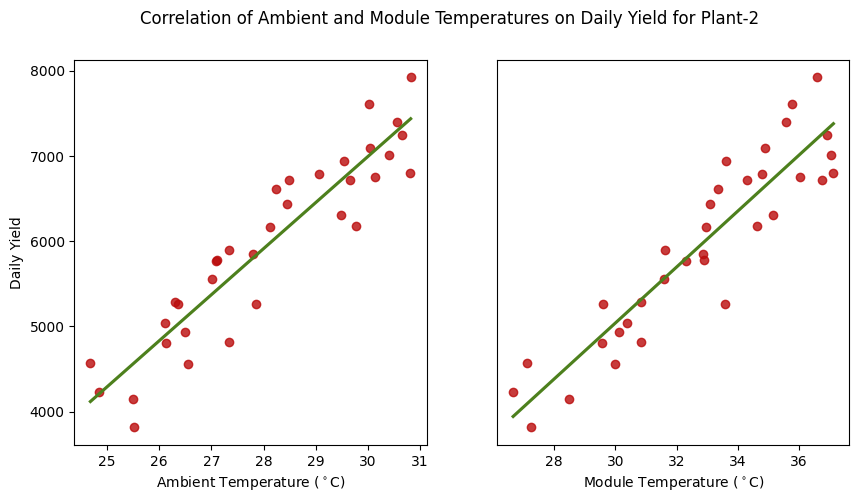

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Correlation of Ambient and Module Temperatures on Daily Yield for Plant-2')
sns.regplot(ax=axes[0],x=df_daily_temp_plant_2['AMBIENT_TEMPERATURE'],y=df_daily_yield[1]['DAILY_YIELD'],line_kws=dict(color="#4d801d"),color="#ba0b0b",ci = None)
axes[0].set_xlabel('Ambient Temperature ($^\circ$C)')
axes[0].set_ylabel('Daily Yield')
sns.regplot(ax=axes[1],x=df_daily_temp_plant_2['MODULE_TEMPERATURE'],y=df_daily_yield[1]['DAILY_YIELD'],line_kws=dict(color="#4d801d"),color="#ba0b0b",ci = None)
axes[1].set_xlabel('Module Temperature ($^\circ$C)')
axes[1].get_yaxis().set_visible(False)
plt.show()

In [32]:
print('plant-1 \n-----')
print(f"correlation between daily yield and ambient temperature: {round(df_daily_yield[0]['DAILY_YIELD'].corr(df_daily_temp_plant_1['AMBIENT_TEMPERATURE']),3)}")
print(f"correlation between daily yield and ambient temperature: {round(df_daily_yield[0]['DAILY_YIELD'].corr(df_daily_temp_plant_1['MODULE_TEMPERATURE']),3)}")

plant-1 
-----
correlation between daily yield and ambient temperature: 0.426
correlation between daily yield and ambient temperature: 0.616


In [33]:
print('plant-2 \n-----')
print(f"correlation between daily yield and ambient temperature: {round(df_daily_yield[1]['DAILY_YIELD'].corr(df_daily_temp_plant_2['AMBIENT_TEMPERATURE']),3)}")
print(f"correlation between daily yield and ambient temperature: {round(df_daily_yield[1]['DAILY_YIELD'].corr(df_daily_temp_plant_2['MODULE_TEMPERATURE']),3)}")

plant-2 
-----
correlation between daily yield and ambient temperature: 0.927
correlation between daily yield and ambient temperature: 0.92


#### Irradiation

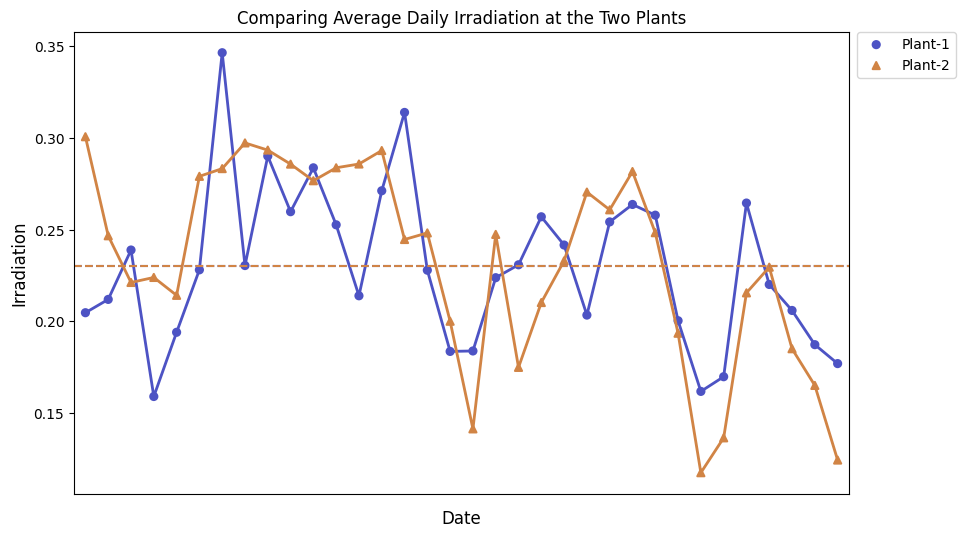

In [34]:
plt.figure(figsize=(10, 6))
fig = sns.pointplot(data=df_daily_temp_plant_1,x='DATE',y='IRRADIATION',color='#4d53c4',label='Plant-1',scale=0.75)
fig = sns.pointplot(data=df_daily_temp_plant_2,x='DATE',y='IRRADIATION',color='#d18445',label='Plant-2',markers='^',scale=0.75)
fig.set(xticklabels=[]) 
fig.tick_params(bottom=False)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.ylabel('Irradiation', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Comparing Average Daily Irradiation at the Two Plants')

plt.axhline(y = round(np.average(df_daily_temp_plant_1['IRRADIATION']),2), color = '#4d53c4', linestyle = 'dashed') 
plt.axhline(y = round(np.average(df_daily_temp_plant_2['IRRADIATION']),2), color = '#d18445', linestyle = 'dashed')

# plt.text(28, 25.8, f"{round(np.average(df_daily_temp_plant_1['AMBIENT_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#4d53c4')
# plt.text(28, 28.3, f"{round(np.average(df_daily_temp_plant_2['AMBIENT_TEMPERATURE']),1)}($^\circ$C)", fontsize = 14,color='#d18445')

plt.show()

#### irradiance vs temperature

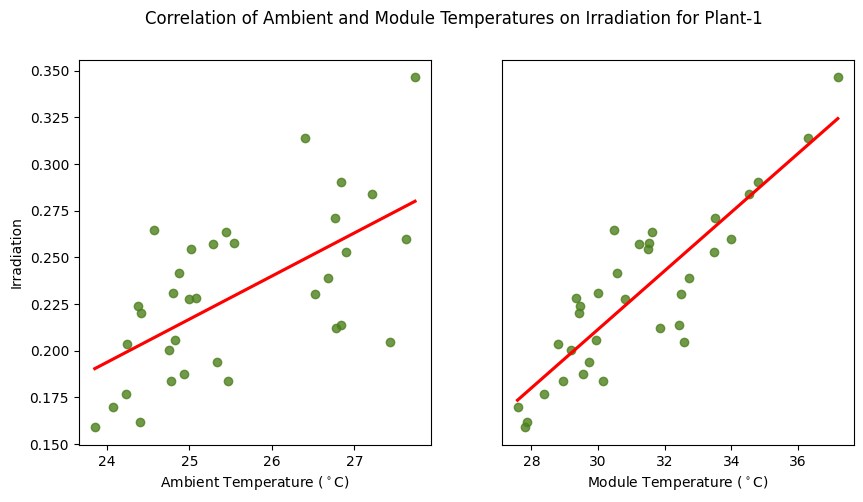

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Correlation of Ambient and Module Temperatures on Irradiation for Plant-1')
sns.regplot(ax=axes[0],x=df_daily_temp_plant_1['AMBIENT_TEMPERATURE'],y=df_daily_temp_plant_1['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[0].set_xlabel('Ambient Temperature ($^\circ$C)')
axes[0].set_ylabel('Irradiation')
sns.regplot(ax=axes[1],x=df_daily_temp_plant_1['MODULE_TEMPERATURE'],y=df_daily_temp_plant_1['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[1].set_xlabel('Module Temperature ($^\circ$C)')
axes[1].get_yaxis().set_visible(False)
plt.show()

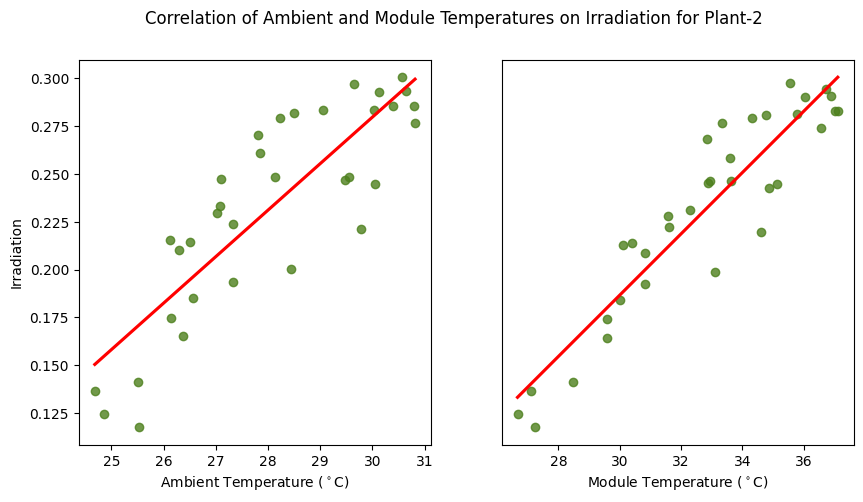

In [36]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Correlation of Ambient and Module Temperatures on Irradiation for Plant-2')
sns.regplot(ax=axes[0],x=df_daily_temp_plant_2['AMBIENT_TEMPERATURE'],y=df_daily_temp_plant_2['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[0].set_xlabel('Ambient Temperature ($^\circ$C)')
axes[0].set_ylabel('Irradiation')
sns.regplot(ax=axes[1],x=df_daily_temp_plant_2['MODULE_TEMPERATURE'],y=df_daily_temp_plant_2['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[1].set_xlabel('Module Temperature ($^\circ$C)')
axes[1].get_yaxis().set_visible(False)
plt.show()

#### irradiance vs daily yield

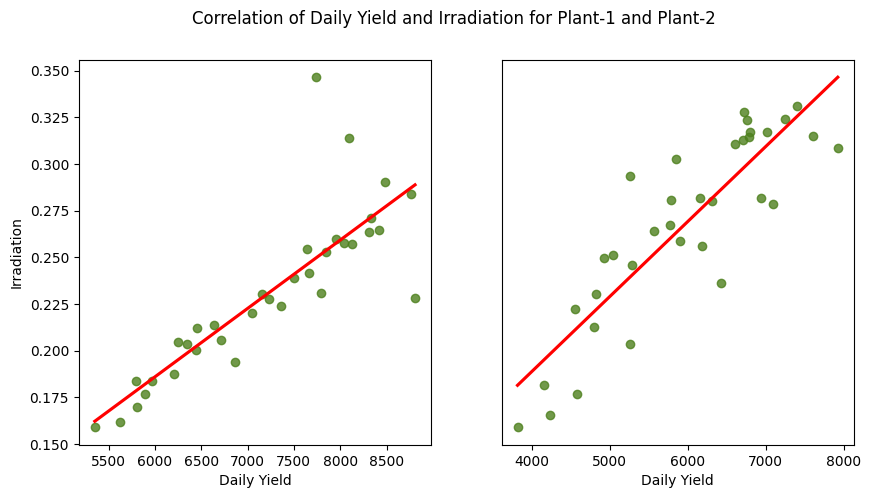

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Correlation of Daily Yield and Irradiation for Plant-1 and Plant-2')
sns.regplot(ax=axes[0],x=df_daily_yield[0]['DAILY_YIELD'],y=df_daily_temp_plant_1['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[0].set_xlabel('Daily Yield')
axes[0].set_ylabel('Irradiation')
sns.regplot(ax=axes[1],x=df_daily_yield[1]['DAILY_YIELD'],y=df_daily_temp_plant_2['IRRADIATION'],line_kws=dict(color="r"),color="#4d801d",ci = None)
axes[1].set_xlabel('Daily Yield')
axes[1].get_yaxis().set_visible(False)
plt.show()

#### To further assess the correlations among different numerical columns, a seaborn pairplot is handy.
#### After joining the datasets for each plant, a set of pairplots will be generated.

In [38]:
df_merged_plant_1 = pd.merge(left=df_daily_yield[0],right=df_daily_temp_plant_1,how='inner',left_on='DATE',right_on='DATE')
df_merged_plant_1.drop(['PLANT_ID_x','PLANT_ID_y'],axis=1,inplace=True)

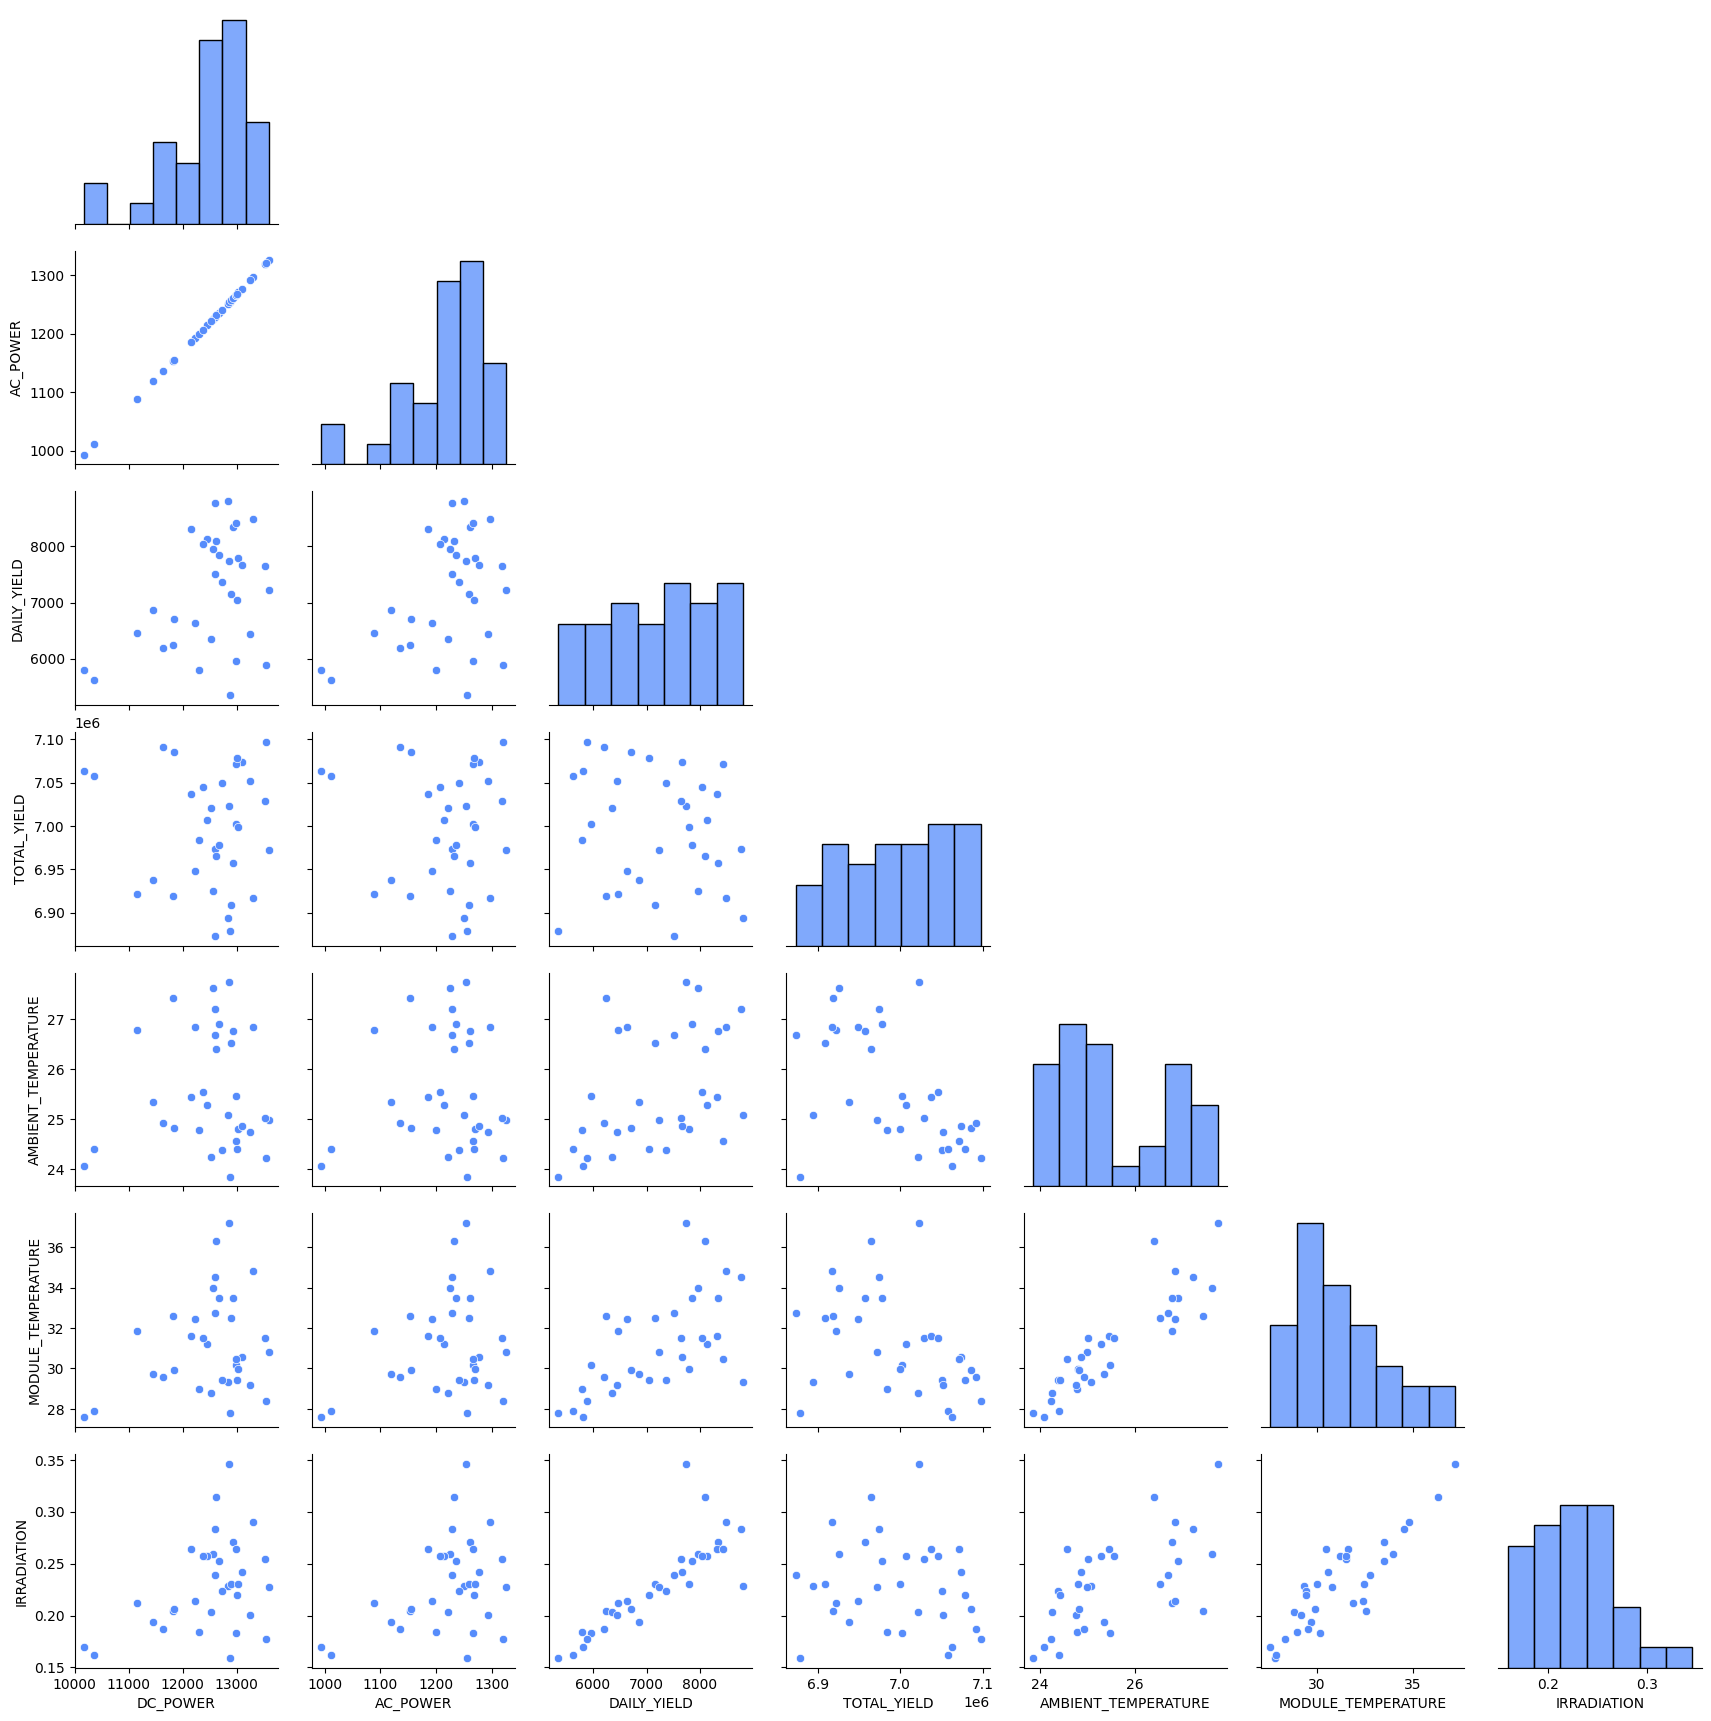

In [39]:
sns.pairplot(data=df_merged_plant_1,corner=True)
plt.show()

In [40]:
df_merged_plant_2 = pd.merge(left=df_daily_yield[1],right=df_daily_temp_plant_2,how='inner',left_on='DATE',right_on='DATE')
df_merged_plant_2.drop(['PLANT_ID_x','PLANT_ID_y'],axis=1,inplace=True)

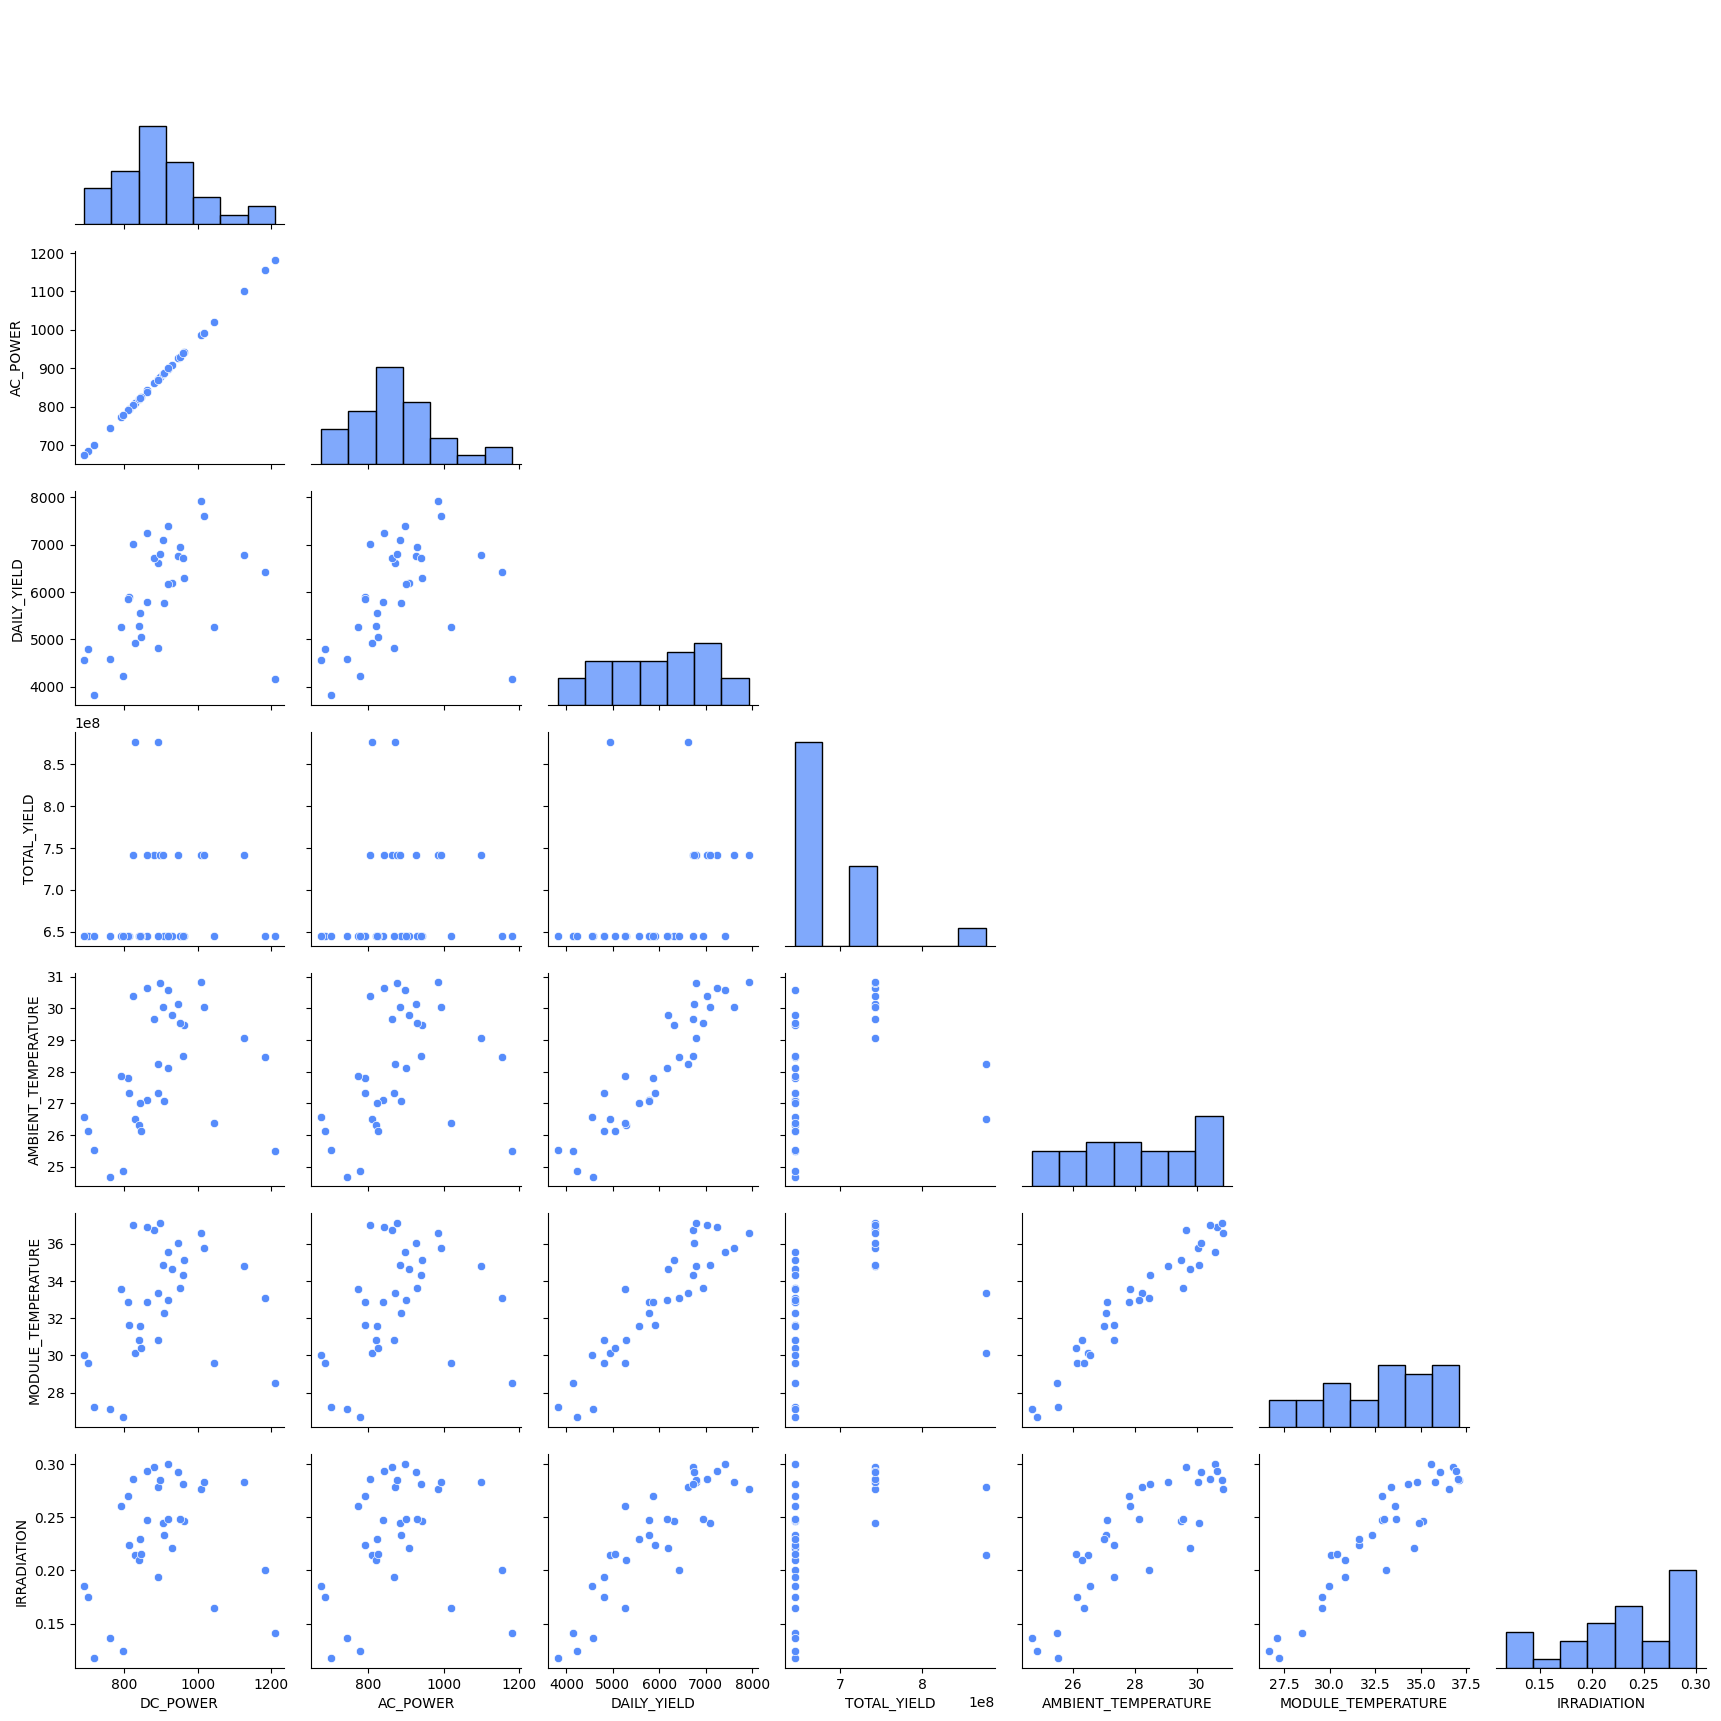

In [41]:
sns.pairplot(data=df_merged_plant_2,corner=True)
plt.show()

### Total Yield
#### Total Yield is expected to continuously increase with time. 
#### The total yield for plant-1 follows this expectation but not plant-2.

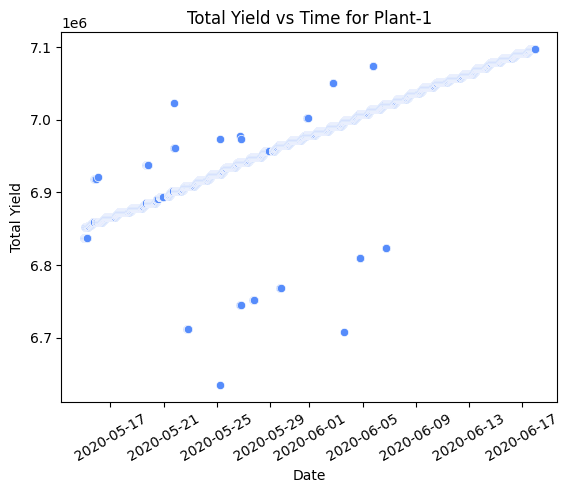

In [42]:
sns.scatterplot(y = df_group[0]['TOTAL_YIELD'],x=df_group[0]['DATE_TIME'])
plt.ylabel('Total Yield')
plt.xlabel('Date')
plt.title('Total Yield vs Time for Plant-1')
plt.tick_params(axis='x', rotation=30)
plt.show()

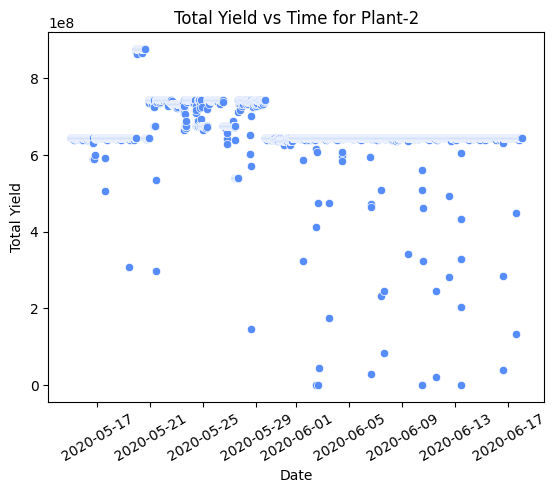

In [43]:
sns.scatterplot(y = df_group[2]['TOTAL_YIELD'],x=df_group[2]['DATE_TIME'])
plt.ylabel('Total Yield')
plt.xlabel('Date')
plt.title('Total Yield vs Time for Plant-2')
plt.tick_params(axis='x', rotation=30)
plt.show()

## Summary
#### 1. Module temperature of a solar plant is directly correlated to the ambient temperature. The module temperature is slightly (a few degree of celsius) higher than the ambient temperature.
#### 2. Plant-2 seems to be located in a warmer region when compared to plant-1.
#### 3. The daily yield of solar plant is linearly related to the module temperature of plant-2. This correlation was not observed for plant-1. 
#### 4. The daily yield of solar plant is linearly related to the irradiation from the sun to the panels.
#### 5. It seems that the DC power data for plant-1 is not recorded correctly.